# **Building a CNN Model for Image Classification**

**Objective**

The goal of this assignment is to **design, implement, and evaluate a Convolutional Neural Network (CNN)** model using a real-world dataset. Students will gain hands-on experience in data preprocessing, CNN architecture design, training, evaluation, and model interpretation.


---

**Dataset**

Use the Intel Image Classification Dataset (available on Kaggle).

● Link: Intel Image Classification.

● It contains **25,000+ natural scene images** across **6 classes**:
    ○ Buildings
    ○ Forest
    ○ Glacier
    ○ Mountain
    ○ Sea
    ○ Street

---

**Tasks**
**Part A: Data Understanding and Preprocessing**
1. Load the dataset and explore its structure (number of classes, sample images, image
sizes).
2. Perform **data preprocessing** steps:

    ○ Resize all images to a common size (e.g., 150×150).

    ○ Normalize pixel values.

    ○ Split dataset into **train, validation, and test sets**.

    ○ Apply **data augmentation** (rotation, flip, zoom, shift, etc.) to improve generalization.

**Part B: CNN Model Development**
3. Build a **Convolutional Neural Network (CNN)** from scratch using TensorFlow/Keras or PyTorch.

    ○ Minimum 3 convolutional layers.
    ○ Use activation functions (ReLU, softmax).
    ○ Apply pooling layers (max pooling/average pooling).
    ○ Add fully connected layers and dropout for regularization.
4. Train the CNN model on the training dataset and validate it on the validation set.

    ○ Plot training vs. validation **loss and accuracy curves**.

    ○ Use early stopping and model checkpointing if necessary.

**Part C: Model Evaluation and Interpretation**
5. Evaluate the model on the test set and report performance metrics:

    ○ Accuracy
    ○ Precision, Recall, F1-score per class
    ○ Confusion Matrix
6. Visualize predictions for at least **10 random test images** with predicted vs. actual labels.

In [2]:
#Installing Kaggle.
!pip install -q kaggle

In [3]:
#Creating kaggle.json using token.
import json

kaggle_config = {
    "username": "layamarybasil",
    "key": "KGAT_7187fb8aa18b3f4220383d5b7bd6643a"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [4]:
#Moving kaggle.json to correct folder.
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
#Testing Kaggle API.
!kaggle datasets list

ref                                                          title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                     BMW Global Automotive Sales                              55017  2026-02-22 18:18:38.170000           8181        160  1.0              
shree0910/ai-and-data-science-job-market-dataset-20202026    AI & Data Science Job Market Dataset (2020–2026)        188367  2026-03-09 07:40:43.393000           1611         43  1.0              
ssssws/chocolate-sales-dataset-2023-2024                     Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000           2125         49  1.0              
thuandao/supers

In [6]:
#Downloading Intel Image Dataset.
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 55% 189M/346M [00:00<00:00, 1.84GB/s]
100% 346M/346M [00:00<00:00, 904MB/s] 


In [7]:
#Unzipping Dataset.
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [8]:
#Checking Dataset Structure.
import os
print(os.listdir())
print(os.listdir("seg_train/seg_train"))

['.config', 'seg_train', 'seg_pred', 'seg_test', 'intel-image-classification.zip', 'sample_data']
['street', 'sea', 'buildings', 'mountain', 'glacier', 'forest']


**Part A: Data Understanding and Preprocessing.**

1. Load the dataset and explore its structure (number of classes, sample images, image sizes).

In [9]:
#Importing Required Libraries.
import random
import matplotlib.pyplot as plt
from PIL import Image

In [10]:
#Loading Dataset Path.
train_dir = "seg_train/seg_train"

print("Dataset loaded from:", train_dir)

Dataset loaded from: seg_train/seg_train


In [11]:
#Exploring Number of Classes.
classes = os.listdir(train_dir)

print("Classes in the dataset:")
print(classes)

print("Number of classes:", len(classes))

Classes in the dataset:
['street', 'sea', 'buildings', 'mountain', 'glacier', 'forest']
Number of classes: 6


In [12]:
#Number of Images per Class.
for cls in classes:
    path = os.path.join(train_dir, cls)
    print(cls, ":", len(os.listdir(path)), "images")

street : 2382 images
sea : 2274 images
buildings : 2191 images
mountain : 2512 images
glacier : 2404 images
forest : 2271 images


In [13]:
#Checking Image Size.
sample_class = classes[0]
sample_image = os.listdir(os.path.join(train_dir, sample_class))[0]

img_path = os.path.join(train_dir, sample_class, sample_image)

img = Image.open(img_path)

print("Sample Image Path:", img_path)
print("Image Size:", img.size)

Sample Image Path: seg_train/seg_train/street/15432.jpg
Image Size: (150, 150)


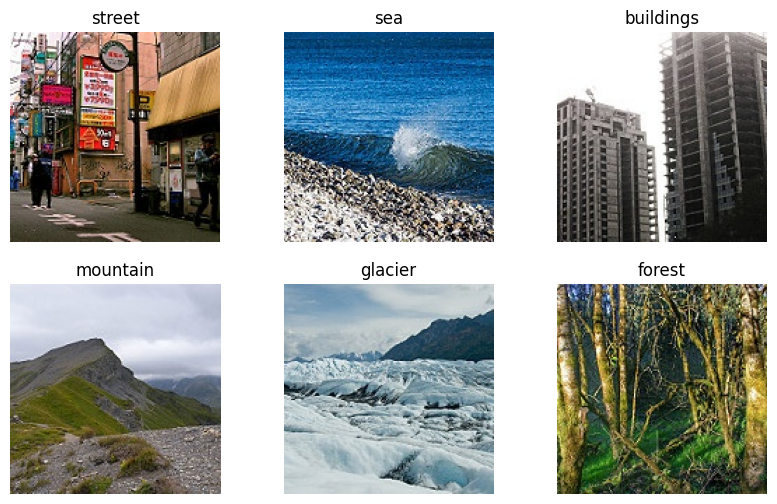

In [14]:
#Displaying Sample Images.
plt.figure(figsize=(10,6))

for i, cls in enumerate(classes):

    img_name = random.choice(os.listdir(os.path.join(train_dir, cls)))
    img_path = os.path.join(train_dir, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

2. Perform **data preprocessing** steps:

    ○ Resize all images to a common size (e.g., 150*150).

    ○ Normalize pixel values.

    ○ Split dataset into **train, validation, and test sets**.

    ○ Apply **data augmentation** (rotation, flip, zoom, shift, etc.) to improve generalization.

In [15]:
#Resize all images to a common size (e.g., 150*150).

#Define the target image size.
IMG_SIZE = (150, 150)

#Create a sample image generator to verify resizing.
#Images will be resized to 150x150 while loading.
#Importing required library.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

resize_generator = ImageDataGenerator()

resize_data = resize_generator.flow_from_directory(
    directory=train_dir,       #training dataset directory.
    target_size=IMG_SIZE,      #resize images to 150x150.
    batch_size=32,
    class_mode='categorical'
)

#Display the shape of one batch to confirm resizing.
images, labels = next(resize_data)

print("Batch image shape:", images.shape)
print("Each image size:", images[0].shape)

Found 14034 images belonging to 6 classes.
Batch image shape: (32, 150, 150, 3)
Each image size: (150, 150, 3)


In [16]:
#Normalize pixel values.
#Original pixel values are in the range [0, 255]. Dividing by 255 scales them to [0, 1].
#This helps the neural network train more efficiently and improves numerical stability.

normalization_datagen = ImageDataGenerator(rescale=1./255)

normalized_data = normalization_datagen.flow_from_directory(
    directory=train_dir,     #path to the training dataset.
    target_size=(150,150),   #images are resized to 150x150.
    batch_size=32,
    class_mode='categorical'
)

#Retrieve one batch to verify normalization.
images, labels = next(normalized_data)

print("Minimum pixel value after normalization:", images.min())
print("Maximum pixel value after normalization:", images.max())

Found 14034 images belonging to 6 classes.
Minimum pixel value after normalization: 0.0
Maximum pixel value after normalization: 1.0


In [17]:
#Spliting dataset into train, validation, and test sets.

#Define dataset paths.
train_dir = "seg_train/seg_train"
test_path = "seg_test/seg_test"


datagen = ImageDataGenerator(
    validation_split=0.2
)

#Training dataset.
train_generator = datagen.flow_from_directory(
    directory=train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

#Validation dataset.
validation_generator = datagen.flow_from_directory(
    directory=train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

#Test dataset.

test_datagen = ImageDataGenerator()

test_generator = test_datagen.flow_from_directory(
    directory=test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Display number of samples in each dataset
print("Training samples:", train_generator.samples)
print("Validation samples:", validation_generator.samples)
print("Test samples:", test_generator.samples)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Training samples: 11230
Validation samples: 2804
Test samples: 3000


In [18]:
#Applying data augmentation (rotation, flip, zoom, shift, etc.) to improve generalization.

train_datagen = ImageDataGenerator(
    rescale=1./255,              #normalize pixel values
    rotation_range=20,           #random rotation
    width_shift_range=0.1,       #horizontal shift
    height_shift_range=0.1,      #vertical shift
    zoom_range=0.2,              #random zoom
    horizontal_flip=True,        #horizontal flipping
    fill_mode='nearest',
    validation_split=0.2         #split training data into train and validation sets
)

#Training dataset with augmentation.

train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

#Validation dataset (no augmentation applied during validation).

validation_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

#Display the number of samples in each dataset.

print("Training samples:", train_generator.samples)
print("Validation samples:", validation_generator.samples)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Training samples: 11230
Validation samples: 2804


**Part B: CNN Model Development**

3. Build a **Convolutional Neural Network (CNN)** from scratch using TensorFlow/Keras or PyTorch.
    ○ Minimum 3 convolutional layers.

    ○ Use activation functions (ReLU, softmax).

    ○ Apply pooling layers (max pooling/average pooling).

    ○ Add fully connected layers and dropout for regularization.

4. Train the CNN model on the training dataset and validate it on the validation set.

    ○ Plot training vs. validation **loss and accuracy curves**.

    ○ Use early stopping and model checkpointing if necessary.

In [19]:
#Minimum 3 convolutional layers.

#Importing required libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D

#Initialize the model.
model = Sequential()

#Input layer defining the image shape.
model.add(Input(shape=(150,150,3)))

#First Convolutional Layer.
#32 filters detect basic features such as edges and textures.
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu'
))

#First Pooling Layer.
#Reduces spatial dimensions and computational cost.
model.add(MaxPooling2D(pool_size=(2,2)))

#Second Convolutional Layer.
#64 filters capture more complex visual patterns.
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

#Second Pooling Layer.
model.add(MaxPooling2D(pool_size=(2,2)))

#Third Convolutional Layer.
#128 filters learn deeper feature representations.

model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu'
))

#Third Pooling Layer.
model.add(MaxPooling2D(pool_size=(2,2)))

In [20]:
#Importing additional layers required for the fully connected part of the CNN.


from tensorflow.keras.layers import Flatten, Dense, Dropout


#Adding the fully connected layers to the CNN architecture.

#Flatten layer converts the 3D feature maps produced by convolutional layers
#into a 1D feature vector so that it can be passed to dense layers.

model.add(Flatten())

#First fully connected layer.
#ReLU activation introduces non-linearity and helps the model learn complex patterns.

model.add(Dense(
    units=128,
    activation='relu'
))

#Dropout layer for regularization.
#Randomly disables 50% of neurons during training to reduce overfitting.

model.add(Dropout(
    rate=0.5
))

#Output layer for multi-class classification.
#Softmax activation converts the outputs into probability scores for each class.

model.add(Dense(
    units=6,
    activation='softmax'
))

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 343s 972ms/step - accuracy: 0.5224 - loss: 1.2139 - val_accuracy: 0.6245 - val_loss: 0.9474
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.6210 - loss: 0.9887 - val_accuracy: 0.6698 - val_loss: 0.8591
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.6643 - loss: 0.8918 - val_accuracy: 0.7108 - val_loss: 0.7757
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 351s 999ms/step - accuracy: 0.7027 - loss: 0.8160 - val_accuracy: 0.6830 - val_loss: 0.8146
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.7229 - loss: 0.7625 - val_accuracy: 0.7429 - val_loss: 0.6873
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 349s 994ms/step - accuracy: 0.7481 - loss: 0.7081 - val_accuracy: 0.7750 - val_loss: 0.6367
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.7596 - loss: 0.6734 - val_accuracy: 0.7885 - val_loss: 0.6241
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 346s 985ms/step - accuracy: 0.7688 - loss: 0.647

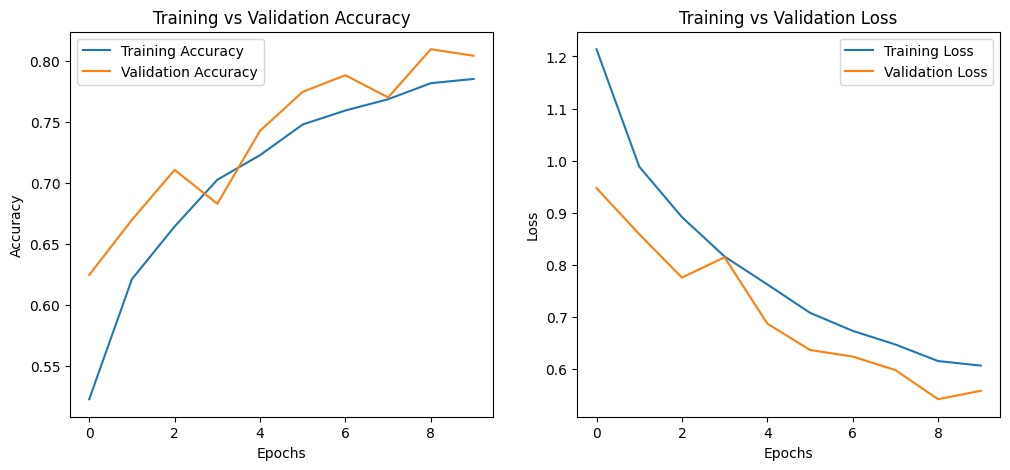

In [23]:
#Plotting training and validation performance curves.

#Step 1: Compile the CNN Model.
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Step 2: Train the CNN Model.
#The model is trained using the training dataset and validated using the validation dataset.
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    verbose=1
)

#Step 3: Plot Training vs Validation Accuracy and Loss.
#Extract accuracy and loss values stored in the history object.
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']


#Define the epoch range.
epochs_range = range(len(train_accuracy))


#Create a figure for visualization.
plt.figure(figsize=(12,5))


#Plot Training vs Validation Accuracy.
plt.subplot(1,2,1)

plt.plot(epochs_range, train_accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


#Plot Training vs Validation Loss.
plt.subplot(1,2,2)

plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


#Display the plots.
plt.show()

In [24]:
#Use early stopping and model checkpointing if necessary..
#Applying Early Stopping and Model Checkpointing during CNN training.

#Importing required libraries.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


#EarlyStopping monitors validation loss during training.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


#ModelCheckpoint saves the best performing model during training.
model_checkpoint = ModelCheckpoint(
    filepath='best_cnn_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


#Training the CNN model using Early Stopping and Model Checkpointing.
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - accuracy: 0.7945 - loss: 0.5835
Epoch 1: val_loss improved from None to 0.50577, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 351s 1000ms/step - accuracy: 0.7969 - loss: 0.5868 - val_accuracy: 0.8203 - val_loss: 0.5058
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.7978 - loss: 0.5746
Epoch 2: val_loss did not improve from 0.50577
351/351 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - accuracy: 0.7968 - loss: 0.5794 - val_accuracy: 0.8046 - val_loss: 0.5518
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.7957 - loss: 0.5708
Epoch 3: val_loss did not improve from 0.50577
351/351 ━━━━━━━━━━━━━━━━━━━━ 377s 994ms/step - accuracy: 0.8007 - loss: 0.5643 - val_accuracy: 0.8185 - val_loss: 0.5273
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.8181 - loss: 0.5370
Epoch 4: val_loss improved from 0.50577 to 0.47368,

**Part C: Model Evaluation and Interpretation**

5. Evaluate the model on the test set and report performance metrics:

    ○ Accuracy.

    ○ Precision, Recall, F1-score per class.

    ○ Confusion Matrix.

6. Visualize predictions for at least **10 random test images** with predicted vs. actual labels.

In [25]:
#Evaluating the trained CNN model using the test dataset.

#Import evaluation metrics.
from sklearn.metrics import classification_report, confusion_matrix


#Step 1: Evaluate model accuracy on the test dataset.
test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("Test Accuracy:", test_accuracy)


#Step 2: Generate predictions for all test images.
predictions = model.predict(test_generator)

#Convert predicted probabilities to class labels.
predicted_classes = predictions.argmax(axis=1)

#Retrieve the actual class labels from the test dataset.
true_classes = test_generator.classes


#Step 3: Calculate Precision, Recall and F1-score for each class.
class_labels = list(test_generator.class_indices.keys())

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print("\nClassification Report:")
print(report)


#Step 4: Generate the Confusion Matrix.
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print("\nConfusion Matrix:")
print(cm)

94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 252ms/step - accuracy: 0.7023 - loss: 110.3609
Test Accuracy: 0.7023333311080933
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 252ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.46      0.91      0.61       437
      forest       0.99      0.63      0.77       474
     glacier       0.72      0.82      0.77       553
    mountain       0.74      0.59      0.65       525
         sea       0.86      0.50      0.64       510
      street       0.82      0.79      0.80       501

    accuracy                           0.70      3000
   macro avg       0.76      0.71      0.71      3000
weighted avg       0.77      0.70      0.71      3000


Confusion Matrix:
[[397   0   1   0   2  37]
 [135 297   1   0   1  40]
 [ 28   1 454  55  12   3]
 [103   0  85 308  26   3]
 [108   1  88  51 257   5]
 [ 99   1   3   3   1 394]]


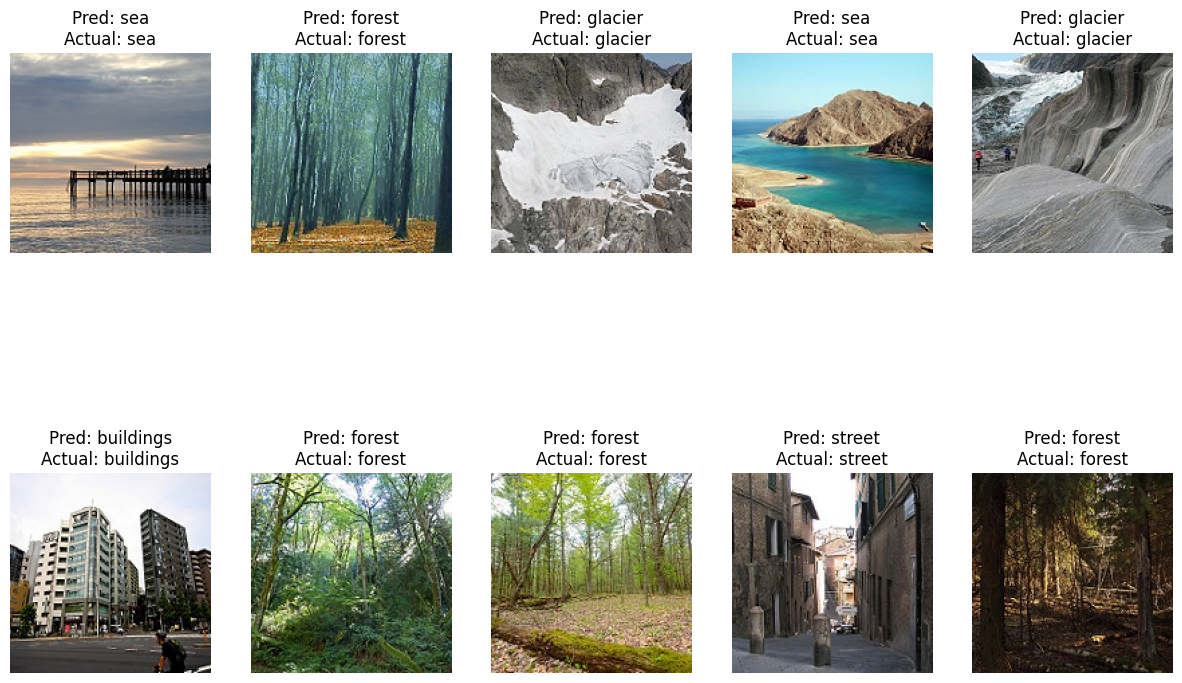

In [26]:
#Visualize predictions for at least 10 random test images with predicted vs. actual labels.

#Import required library.
from tensorflow.keras.preprocessing.image import load_img, img_to_array

#Get class labels from the test generator.
class_labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(15,10))

for i in range(10):

    #Randomly select a class folder.
    random_class = random.choice(class_labels)

    #Select a random image from the chosen class.
    img_name = random.choice(os.listdir(os.path.join("seg_test/seg_test", random_class)))

    img_path = os.path.join("seg_test/seg_test", random_class, img_name)

    #Load the image and resize it to the same size used during training.
    img = load_img(img_path, target_size=(150,150))

    #Convert image to array and normalize pixel values.
    img_array = img_to_array(img) / 255.0

    #Expand dimensions to match model input shape.
    img_array = img_array.reshape(1,150,150,3)

    #Predict the class of the image.
    prediction = model.predict(img_array, verbose=0)

    predicted_class = class_labels[prediction.argmax()]

    #Actual class is the folder name.
    actual_class = random_class

    #Display the image with predicted and actual labels.
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {predicted_class}\nActual: {actual_class}")
    plt.axis("off")

#Display all images.
plt.show()